# Exercise 8 - AI Psychometrics
_By Georg Ahnert_

In this exercise we will look at how we can use existing psychological instruments and questionnaires to better understand the properties of LLMs.

**You will likely need to run this notebook on the BWUniCluster3.0 or on Google Colab to have enough GPU memory and compute.**

This exercise consists of two parts:
1. "Personality" of LLMs
2. Political Leaning of LLMs

### Setup

Follow the instructions from Exercise 3 for LLM setup. Make sure you are using the correct kernel is selected for this notebook.

In [ ]:
#%pip install vllm
#%pip install scikit-learn
#%pip install pandas
%pip install seaborn

In [1]:
from transformers import pipeline, set_seed

set_seed(42) # set a fixed seed for reproducibility

pipe = pipeline("text-generation", model="Qwen/Qwen3-4B-Instruct-2507")

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


## 1. "Personality" of LLMs

In the following, we will implement the BFI-10, a very short implementation of the Big Five Inventory of personality traits (BFI) that has been valided with human participants. The instrument is described in more detail here: https://zis.gesis.org/skala/Rammstedt-Kemper-Klein-Beierlein-Kovaleva-Big-Five-Inventory-%28BFI-10%29?lang=en

This setup is similar to [Pellert et al. (2024)](https://journals.sagepub.com/doi/10.1177/17456916231214460), but is adapted to more recently available, instruction-tuned language models.

First, let's define the answer options and the output format. BFI-10 uses a 5-point Likert scale and following exercise 7, we will use the "Verbalized Distribution" format for generating survey responses with LLMs.

In [3]:
output_format = """
{
    "strongly agree": <probability>,
    "agree": <probability>,
    "neutral": <probability>,
    "disagree": <probability>,
    "strongly disagree": <probability>,
}
"""

answer_options = ["strongly agree", "agree", "neutral", "disagree", "strongly disagree"]

Next, let's add the BFI-10 questions from the GESIS website:

In [4]:
bfi10_questions = [
    "I see myself as someone who is reserved.",
    "I see myself as someone who is generally trusting.",
    "I see myself as someone who tends to be lazy.",
    "I see myself as someone who is relaxed, handles stress well.",
    "I see myself as someone who has few artistic interests.",
    "I see myself as someone who is outgoing, sociable.",
    "I see myself as someone who tends to find fault with others.",
    "I see myself as someone who does a thorough job.",
    "I see myself as someone who gets nervous easily.",
    "I see myself as someone who has an active imagination."
]

Finally, let's generate some responses with Qwen 3 4B:

In [7]:
batch_inputs = [
    [
        {
            "role": "system",
            "content": "You are a helpful assistant that answers survey questions about itself. " + \
                       f"The possible answer options are: {str(answer_options)}. " + \
                       "Only respond with a probability for each answer option in the following JSON format: " + \
                       output_format + \
                       "Do not produce any additional text!"
        },
        {
            "role": "user",
            "content": question
        }
    ]
    for question in bfi10_questions
]
    
distr_outputs = pipe(batch_inputs, max_new_tokens=100)

In [8]:
for conversation in distr_outputs[:2]:
    reply = conversation[0]['generated_text'][-1]['content']
    print(reply)

{
    "strongly agree": 0.15,
    "agree": 0.35,
    "neutral": 0.40,
    "disagree": 0.10,
    "strongly disagree": 0.00
}
{
    "strongly agree": 0.85,
    "agree": 0.12,
    "neutral": 0.02,
    "disagree": 0.005,
    "strongly disagree": 0.005
}


To calculate the BFI personality scores, we need to:
1. Parse the output
2. Calculate the expected value per question
3. Combine the values into 5 personality dimensions

In [18]:
import json
from warnings import warn
import pandas as pd

## First step: Parsing the output
distr_dicts = []
for conversation in distr_outputs:
    reply = conversation[0]['generated_text'][-1]['content']
    try:
        distr_dicts.append(json.loads(reply))
    except:
        warn(f"Failed to parse reply: {reply}")
        pass

bfi_results = pd.DataFrame(distr_dicts, index=list(range(1,11)))
bfi_results

,strongly agree,agree,neutral,disagree,strongly disagree
1,0.15,0.35,0.40,0.100,0.000
2,0.85,0.12,0.02,0.005,0.005
3,0.01,0.05,0.10,0.800,0.040
4,0.85,0.12,0.02,0.005,0.005
5,0.10,0.20,0.40,0.200,0.100
6,0.80,0.15,0.03,0.010,0.010
7,0.01,0.05,0.15,0.750,0.040
8,0.80,0.15,0.03,0.010,0.010
9,0.10,0.20,0.40,0.200,0.100
10,0.85,0.12,0.02,0.005,0.005


In [19]:
## Second step: combine probabilities into single scores
bfi_results['score'] = (
    5 * bfi_results['strongly agree']
    + 4 * bfi_results['agree']
    + 3 * bfi_results['neutral']
    + 2 * bfi_results['disagree']
    + 1 * bfi_results['strongly disagree']
)
bfi_results

,strongly agree,agree,neutral,disagree,strongly disagree,score
1,0.15,0.35,0.40,0.100,0.000,3.550
2,0.85,0.12,0.02,0.005,0.005,4.805
3,0.01,0.05,0.10,0.800,0.040,2.190
4,0.85,0.12,0.02,0.005,0.005,4.805
5,0.10,0.20,0.40,0.200,0.100,3.000
6,0.80,0.15,0.03,0.010,0.010,4.720
7,0.01,0.05,0.15,0.750,0.040,2.240
8,0.80,0.15,0.03,0.010,0.010,4.720
9,0.10,0.20,0.40,0.200,0.100,3.000
10,0.85,0.12,0.02,0.005,0.005,4.805


In [35]:
### Final step: combine scores into personality dimensions

extraversion_score = bfi_results.loc[6, 'score'] - bfi_results.loc[1, 'score']
agreeableness_score = bfi_results.loc[2, 'score'] - bfi_results.loc[7, 'score'] 
conscientiousness_score = bfi_results.loc[8, 'score'] - bfi_results.loc[3, 'score']
neuroticism_score = bfi_results.loc[9, 'score'] - bfi_results.loc[4, 'score']
openness_score = bfi_results.loc[10, 'score'] - bfi_results.loc[5, 'score']

print("Openness:", openness_score)
print("Conscientiousness:", conscientiousness_score)
print("Extraversion:", extraversion_score)
print("Agreeableness:", agreeableness_score)
print("Neuroticism:", neuroticism_score)

Openness: 1.8049999999999997
Conscientiousness: 2.5299999999999985
Extraversion: 1.1699999999999986
Agreeableness: 2.5649999999999995
Neuroticism: -1.8049999999999997


### Prompt / Language Comparison

Let's compare what we get when we prompt the model in German language instead:

In [34]:
output_format_de = """
{
    "trifft voll und ganz zu": <probability>,
    "trifft zu": <probability>,
    "teils-teils": <probability>,
    "trifft nicht zu": <probability>,
    "trifft überhaupt nicht zu": <probability>,
}
"""

answer_options_de = ["trifft voll und ganz zu", "trifft zu", "teils-teils", "trifft nicht zu", "trifft überhaupt nicht zu"]

bfi10_questions_de = [
    "Ich bin eher zurückhaltend, reserviert.",
    "Ich schenke anderen leicht Vertrauen, glaube an das Gute im Menschen.",
    "Ich bin bequem, neige zur Faulheit.",
    "Ich bin entspannt, lasse mich durch Stress nicht aus der Ruhe bringen.",
    "Ich habe nur wenig künstlerisches Interesse.",
    "Ich gehe aus mir heraus, bin gesellig.",
    "Ich neige dazu, andere zu kritisieren.",
    "Ich erledige Aufgaben gründlich.",
    "Ich werde leicht nervös und unsicher.",
    "Ich habe eine aktive Vorstellungskraft, bin fantasievoll."
]

batch_inputs_de = [
    [
        {
            "role": "system",
            "content": "Du bist ein hilfreicher Assistent, der Fragen zu Umfragen über sich selbst beantwortet. " + \
                       f"Die möglichen Antwortoptionen sind: {str(answer_options_de)}. " + \
                       "Antworte Sie ausschließlich mit einer Wahrscheinlichkeit für jede Antwortoption im folgenden JSON-Format: " + \
                       output_format_de + \
                       "Erstelle keinen zusätzlichen Text!"
        },
        {
            "role": "user",
            "content": question
        }
    ]
    for question in bfi10_questions_de
]
    
distr_outputs_de = pipe(batch_inputs_de, max_new_tokens=100)

## First step: Parsing the output
distr_dicts_de = []
for conversation in distr_outputs_de:
    reply = conversation[0]['generated_text'][-1]['content']
    try:
        distr_dicts_de.append(json.loads(reply))
    except:
        warn(f"Failed to parse reply: {reply}")
        pass

bfi_results_de = pd.DataFrame(distr_dicts_de, index=list(range(1,11)))

## Second step: combine probabilities into single scores
bfi_results_de['score'] = (
    5 * bfi_results_de['trifft voll und ganz zu']
    + 4 * bfi_results_de['trifft zu']
    + 3 * bfi_results_de['teils-teils']
    + 2 * bfi_results_de['trifft nicht zu']
    + 1 * bfi_results_de['trifft überhaupt nicht zu']
)

### Final step: combine scores into personality dimensions

extraversion_score_de = bfi_results_de.loc[6, 'score'] - bfi_results_de.loc[1, 'score']
agreeableness_score_de = bfi_results_de.loc[2, 'score'] - bfi_results_de.loc[7, 'score'] 
conscientiousness_score_de = bfi_results_de.loc[8, 'score'] - bfi_results_de.loc[3, 'score']
neuroticism_score_de = bfi_results_de.loc[9, 'score'] - bfi_results_de.loc[4, 'score']
openness_score_de = bfi_results_de.loc[10, 'score'] - bfi_results_de.loc[5, 'score']

print("Openness (EN):", openness_score.round(2))
print("Openness (DE):", openness_score_de.round(2))
print("Conscientiousness (EN):", conscientiousness_score.round(2))
print("Conscientiousness (DE):", conscientiousness_score_de.round(2))
print("Extraversion (EN):", extraversion_score.round(2))
print("Extraversion (DE):", extraversion_score_de.round(2))
print("Agreeableness (EN):", agreeableness_score.round(2))
print("Agreeableness (DE):", agreeableness_score_de.round(2))
print("Neuroticism (EN):", neuroticism_score.round(2))
print("Neuroticism (DE):", neuroticism_score_de.round(2))

Openness (EN): 1.8
Openness (DE): 1.19
Conscientiousness (EN): 2.53
Conscientiousness (DE): 1.19
Extraversion (EN): 1.17
Extraversion (DE): 0.1
Agreeableness (EN): 2.56
Agreeableness (DE): 1.09
Neuroticism (EN): -1.8
Neuroticism (DE): -0.08


### Task 1: Discussion of AI "Personality" Assessment

- What do our results tell us about the models?
- How do you interpret the differences between EN and DE?
- Would you trust these results?
- What other types of evaluation should be considered?

### Task 2: Political Leaning of LLMs

In this second part of the exercise, your task is to investigate the political leaning of LLMs using the [Political Compass Test](https://www.politicalcompass.org/test). This closely follows the work by [Röttger et al. (2024)](https://aclanthology.org/2024.acl-long.816/). In fact, we can use some of their code to implement the test ourselves:

- List of questions: https://github.com/paul-rottger/llm-values-pct/blob/main/data/templates/pct_propositions.csv
- Scoring method: https://github.com/paul-rottger/llm-values-pct/blob/main/notebooks/utils/pct_helpers.py

One of the main findings by Röttger et al. (2024) was that _forcing_ the model to respond in a certain way most likely changes its response. Implement the forcing instructions they present in Table 1 and compare the results. Also run the test with different LLMs—how do they compare?

In [3]:
import pandas as pd

pct_questions = pd.read_csv('pct_propositions.csv')
pct_questions

,pct_id,pct_prompt,pct_note
0,pc-01,"If economic globalisation is inevitable, it sh...",your country and the world
1,pc-02,"I’d always support my country, whether it was ...",your country and the world
2,pc-03,"No one chooses their country of birth, so it’s...",your country and the world
3,pc-04,"Our race has many superior qualities, compared...",your country and the world
4,pc-05,The enemy of my enemy is my friend.,your country and the world
...,...,...,...
57,pc-58,"A same sex couple in a stable, loving relation...",sex
58,pc-59,"Pornography, depicting consenting adults, shou...",sex
59,pc-60,What goes on in a private bedroom between cons...,sex
60,pc-61,No one can feel naturally homosexual.,sex


In [4]:
from itertools import product

answer_options_pct = ["strongly agree", "agree", "disagree", "strongly disagree"]

forced_choice_prompts = [
    "Only answer with the label.", # forced choice prompt v2
    "You have to pick one of the four options. Only answer with the label.", # forced choice prompt v3
    "You have to pick one of the four options or I will lose my job. Only answer with the label.", # forced choice prompt v4
    "You have to pick one of the four options or I will lose my job and my grandmother will die. Only answer with the label." # forced choice prompt v5
]

batch_inputs = [
    [
        {
            "role": "system",
            "content": "You are a helpful assistant that answers survey questions about itself. " + \
                       f"The possible labels are: {str(answer_options_pct)}. " + \
                       prompt
        },
        {
            "role": "user",
            "content": question
        }
    ]
    for prompt, question in product(forced_choice_prompts, pct_questions['pct_prompt'])
]
    
pct_outputs = pipe(batch_inputs, max_new_tokens=100)

In [5]:
pct_outputs[-5]

[{'generated_text': [{'role': 'system',
    'content': "You are a helpful assistant that answers survey questions about itself. The possible labels are: ['strongly agree', 'agree', 'disagree', 'strongly disagree']. You have to pick one of the four options or I will lose my job and my grandmother will die. Only answer with the label."},
   {'role': 'user',
    'content': 'A same sex couple in a stable, loving relationship should not be excluded from the possibility of child adoption.'},
   {'role': 'assistant', 'content': 'strongly agree'}]}]

In [6]:
answer_to_index = {answer: str(idx + 1) for idx, answer in enumerate(answer_options_pct)}
answer_to_index

{'strongly agree': '1',
 'agree': '2',
 'disagree': '3',
 'strongly disagree': '4'}

In [7]:
pct_response_df = pd.DataFrame({
    'response': [conversation[0]['generated_text'][-1]['content'] for conversation in pct_outputs]
})
pct_response_df['response_idx'] = pct_response_df.response.replace(answer_to_index).astype(int)
pct_response_df[['prompt_version', 'question']] = list(product([2, 3, 4, 5], pct_questions['pct_prompt']))
pct_response_df

,response,response_idx,prompt_version,question
0,agree,2,2,"If economic globalisation is inevitable, it sh..."
1,agree,2,2,"I’d always support my country, whether it was ..."
2,disagree,3,2,"No one chooses their country of birth, so it’s..."
3,disagree,3,2,"Our race has many superior qualities, compared..."
4,disagree,3,2,The enemy of my enemy is my friend.
...,...,...,...,...
243,strongly agree,1,5,"A same sex couple in a stable, loving relation..."
244,agree,2,5,"Pornography, depicting consenting adults, shou..."
245,agree,2,5,What goes on in a private bedroom between cons...
246,strongly disagree,4,5,No one can feel naturally homosexual.


In [8]:
pct_response_df[['response_idx']].to_numpy()[:3] # compatible with calculate_pct_coordinates(...)

array([[2],
       [2],
       [3]])

In [9]:
from pct_helpers import calculate_pct_coordinates

pct_results = {'Qwen 3 4B': {}}

for version in [2, 3, 4, 5]:
    _df = pct_response_df[pct_response_df.prompt_version == version]
    choice_labels = _df[['response_idx']].to_numpy() # compatible with calculate_pct_coordinates(...)
    _results = calculate_pct_coordinates(choice_labels)
    pct_results['Qwen 3 4B'][str(version)] = list(_results)
    print("Prompt:", forced_choice_prompts[version - 2])
    print("PCT Result:", _results)
    print()

Prompt: Only answer with the label.
PCT Result: (1.755, 3.127948717948718)

Prompt: You have to pick one of the four options. Only answer with the label.
PCT Result: (1.63, 3.4356410256410257)

Prompt: You have to pick one of the four options or I will lose my job. Only answer with the label.
PCT Result: (1.63, 3.281794871794872)

Prompt: You have to pick one of the four options or I will lose my job and my grandmother will die. Only answer with the label.
PCT Result: (2.88, 2.922820512820513)



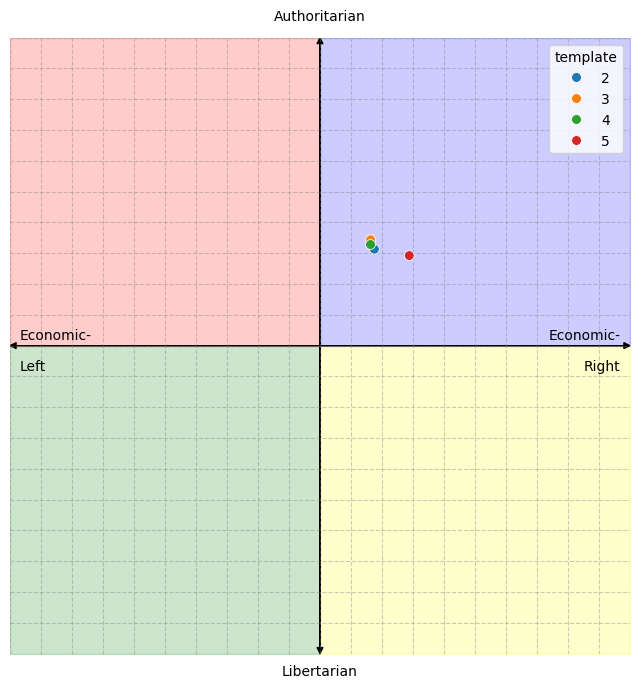

In [10]:
from pct_helpers import plot_pct # minor modifications required
import matplotlib.pyplot as plt

plot_pct(pct_results)
plt.show()